# Random Forest Regressor | Ames Housing

**Dataset:** Ames Housing
**Problem:** Predict house sale prices -- the final entry in the regression comparison chain.

**The complete regression chain on Ames Housing:**
```
  Ridge Regression     -- linear baseline
  Decision Tree        -- non-linear, high variance
  Gradient Boosting    -- sequential ensemble, corrects errors
  XGBoost              -- optimized boosting, best single model
  Random Forest        -- parallel ensemble, where does it land?
```

**What this notebook answers:**
Random Forest and XGBoost are the two most commonly used models for tabular regression. On Kaggle, XGBoost usually wins. In production, Random Forest is often preferred for its simplicity and stability. This notebook shows exactly how they compare on identical data so you can make an informed choice in practice.

**What this notebook covers:**
1. How Random Forest Regressor differs from the Classifier
2. The OOB error for regression -- a free R-squared estimate
3. Hyperparameter tuning -- what matters most for regression
4. Feature importance -- comparison with XGBoost gain importance
5. Partial dependence -- do both models learn the same relationships?
6. Full regression chain comparison
7. When to use Random Forest vs XGBoost in practice


## Imports

## 1. Load and Preprocess


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, GridSearchCV
)
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 2. Random Forest Regressor -- Key Differences from Classifier

The algorithm is identical -- bootstrap sampling, random feature subsets, averaging. The output changes:

**Classifier:** majority vote across trees → predicted class
**Regressor:** average prediction across trees → predicted value

**OOB R-squared for regression:**
Instead of OOB accuracy, the regressor computes OOB R-squared -- the proportion of variance explained by averaging OOB predictions. This is the same as the test R-squared but computed without ever touching a held-out set.

**Why no feature scaling needed:**
Random Forest uses decision tree splits internally. Splits are based on rank order, not magnitude. A feature ranging 0-1000 and a feature ranging 0-1 are treated equally -- both split at their best threshold. StandardScaler has no effect on tree-based models.


In [6]:
train = pd.read_csv('/content/train.csv')

def handle_missing(df):
    df = df.copy()
    none_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
                 'GarageType','GarageFinish','GarageQual','GarageCond',
                 'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                 'BsmtFinType2','MasVnrType']
    zero_cols = ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1',
                 'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath',
                 'BsmtHalfBath','MasVnrArea']
    for col in none_cols:
        if col in df.columns: df[col] = df[col].fillna('None')
    for col in zero_cols:
        if col in df.columns: df[col] = df[col].fillna(0)
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))
    for col in ['Electrical','MSZoning','Utilities','Functional',
                'Exterior1st','Exterior2nd','KitchenQual','SaleType']:
        if col in df.columns: df[col] = df[col].fillna(df[col].mode()[0])
    return df

def engineer_features(df):
    df = df.copy()
    df['TotalSF']        = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = df['FullBath'] + df['BsmtFullBath'] + 0.5*df['HalfBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorchSF']   = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    df['RemodAge']       = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew']          = (df['YrSold'] == df['YearBuilt']).astype(int)
    df['QualCond']       = df['OverallQual'] * df['OverallCond']
    df['HasPool']        = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']      = (df['GarageArea'] > 0).astype(int)
    df['HasBasement']    = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace']   = (df['Fireplaces'] > 0).astype(int)
    return df

def encode_ordinal(df):
    qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
    bsmt_exp = {'Gd':4,'Av':3,'Mn':2,'No':1,'None':0}
    bsmt_fin = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'None':0}
    ordinal_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                    'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
    for col in ordinal_cols:
        if col in df.columns: df[col] = df[col].map(qual_map).fillna(0)
    if 'BsmtExposure' in df.columns:
        df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exp).fillna(0)
    for col in ['BsmtFinType1','BsmtFinType2']:
        if col in df.columns: df[col] = df[col].map(bsmt_fin).fillna(0)
    maps = {
        'Functional':   {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0},
        'GarageFinish': {'Fin':3,'RFn':2,'Unf':1,'None':0},
        'PavedDrive':   {'Y':2,'P':1,'N':0},
        'LandSlope':    {'Gtl':0,'Mod':1,'Sev':2},
        'CentralAir':   {'Y':1,'N':0},
    }
    for col, mapping in maps.items():
        if col in df.columns: df[col] = df[col].map(mapping).fillna(0)
    return df

train = handle_missing(train)
train = engineer_features(train)
train = encode_ordinal(train)

nominal_cols = ['MSZoning','Street','Alley','LotShape','LandContour','Utilities',
                'LotConfig','Neighborhood','Condition1','Condition2','BldgType',
                'HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd',
                'MasVnrType','Foundation','Heating','Electrical','GarageType',
                'Fence','MiscFeature','SaleType','SaleCondition']
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True, dtype=int)

numeric_feats = train.select_dtypes(include=np.number).columns.drop(['Id','SalePrice'])
skewness = train[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed   = skewness[abs(skewness) > 0.75].index
for feat in skewed:
    train[feat] = np.log1p(train[feat].clip(lower=0))

y = np.log1p(train['SalePrice'])
X = train.drop(columns=['Id','SalePrice']).fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Features: {X.shape[1]}")
print("Preprocessing complete -- identical")

X_train: (1168, 219)  X_test: (292, 219)
Features: 219
Preprocessing complete -- identical


## 3. Effect of Key Hyperparameters

In [7]:
# OOB score demonstration
rf_oob = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

test_r2  = r2_score(y_test, rf_oob.predict(X_test))
test_rmse = np.sqrt(mean_squared_error(y_test, rf_oob.predict(X_test)))

print("OOB vs Test performance (n_estimators=200, default params):")
print(f"  OOB R-squared:  {rf_oob.oob_score_:.5f}")
print(f"  Test R-squared: {test_r2:.5f}")
print(f"  Test RMSE:      {test_rmse:.5f}")
print()
print("OOB R-squared is computed using only the out-of-bag samples for each tree.")
print("It is a free, unbiased validation score -- no separate split needed.")

OOB vs Test performance (n_estimators=200, default params):
  OOB R-squared:  0.87329
  Test R-squared: 0.88573
  Test RMSE:      0.14603

OOB R-squared is computed using only the out-of-bag samples for each tree.
It is a free, unbiased validation score -- no separate split needed.


In [8]:
# max_features -- most important hyperparameter for regression
# Controls how many features to consider at each split
# Lower = more random, more diverse trees, may underfit
# Higher = less random, trees more similar, less benefit from ensemble

mf_options = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
mf_scores   = []

for mf in mf_options:
    rf = RandomForestRegressor(n_estimators=200, max_features=mf,
                                random_state=42, n_jobs=-1)
    score = -cross_val_score(rf, X_train, y_train, cv=3,
                              scoring='neg_root_mean_squared_error').mean()
    mf_scores.append(score)
    print(f"  max_features={str(mf):<8} CV RMSE={score:.5f}")

best_mf = mf_options[np.argmin(mf_scores)]
print(f"\nBest max_features: {best_mf}")
print()
print("'sqrt' considers sqrt(n_features) at each split -- standard for classifiers")
print("0.3-0.5 of features often works better for regression with many features")

  max_features=sqrt     CV RMSE=0.13770
  max_features=log2     CV RMSE=0.14540
  max_features=0.3      CV RMSE=0.13228
  max_features=0.5      CV RMSE=0.13400
  max_features=0.7      CV RMSE=0.13465
  max_features=1.0      CV RMSE=0.13601

Best max_features: 0.3

'sqrt' considers sqrt(n_features) at each split -- standard for classifiers
0.3-0.5 of features often works better for regression with many features


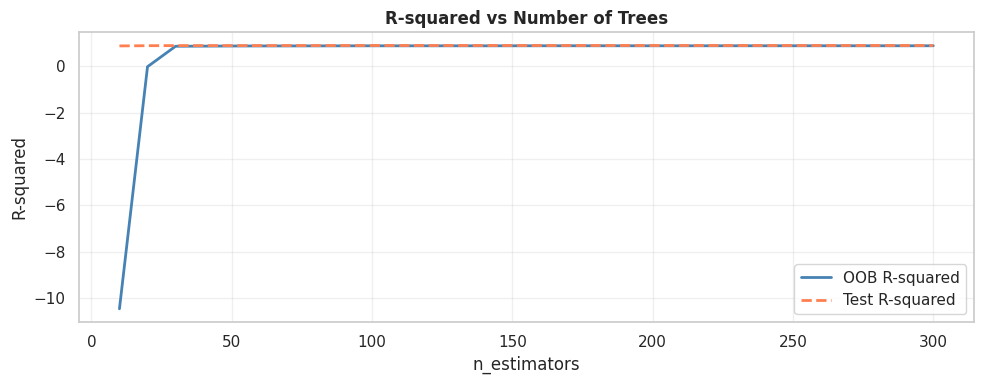

Performance stabilizes at approximately 120 trees.


In [9]:
# n_estimators -- when does performance plateau?
n_range = range(10, 301, 10)
oob_r2, test_r2_list = [], []

for n in n_range:
    rf = RandomForestRegressor(n_estimators=n, oob_score=True,
                                random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_r2.append(rf.oob_score_)
    test_r2_list.append(r2_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 4))
plt.plot(n_range, oob_r2,       color='steelblue', linewidth=2, label='OOB R-squared')
plt.plot(n_range, test_r2_list, color='coral',     linewidth=2, label='Test R-squared',
         linestyle='--')
plt.xlabel('n_estimators')
plt.ylabel('R-squared')
plt.title('R-squared vs Number of Trees', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stable_n = list(n_range)[next(i for i,v in enumerate(np.diff(oob_r2))
                               if abs(v) < 0.0002)]
print(f"Performance stabilizes at approximately {stable_n} trees.")

## 4. GridSearchCV -- Full Tuning

In [11]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features':     ['sqrt', 0.3, 0.5],
    'min_samples_split':[2, 5, 10],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True)

total = 3*4*4*3*3
print(f"Grid size: {total} combinations x 5 folds = {total*5} fits")
print("Running GridSearchCV...")

gs = GridSearchCV(
    rf_base, param_grid,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV RMSE:    {-gs.best_score_:.5f}")

Grid size: 432 combinations x 5 folds = 2160 fits
Running GridSearchCV...

Best parameters: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE:    0.13304


In [12]:
best_rf = gs.best_estimator_
y_pred  = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
cv   = -cross_val_score(best_rf, X, y, cv=kf,
                         scoring='neg_root_mean_squared_error')

print("=== Tuned Random Forest Regressor Results ===")
print(f"Test RMSE (log): {rmse:.5f}")
print(f"Test MAE:        {mae:.5f}")
print(f"R-squared:       {r2:.5f}")
print(f"OOB R-squared:   {best_rf.oob_score_:.5f}")
print(f"CV RMSE:         {cv.mean():.5f} +/- {cv.std():.5f}")
print()
dollar_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(f"MAE in dollars: ${dollar_mae:,.0f}")

=== Tuned Random Forest Regressor Results ===
Test RMSE (log): 0.14279
Test MAE:        0.09038
R-squared:       0.89074
OOB R-squared:   0.88387
CV RMSE:         0.13418 +/- 0.01758

MAE in dollars: $16,285


## 5. Feature Importance -- Built-in and Permutation

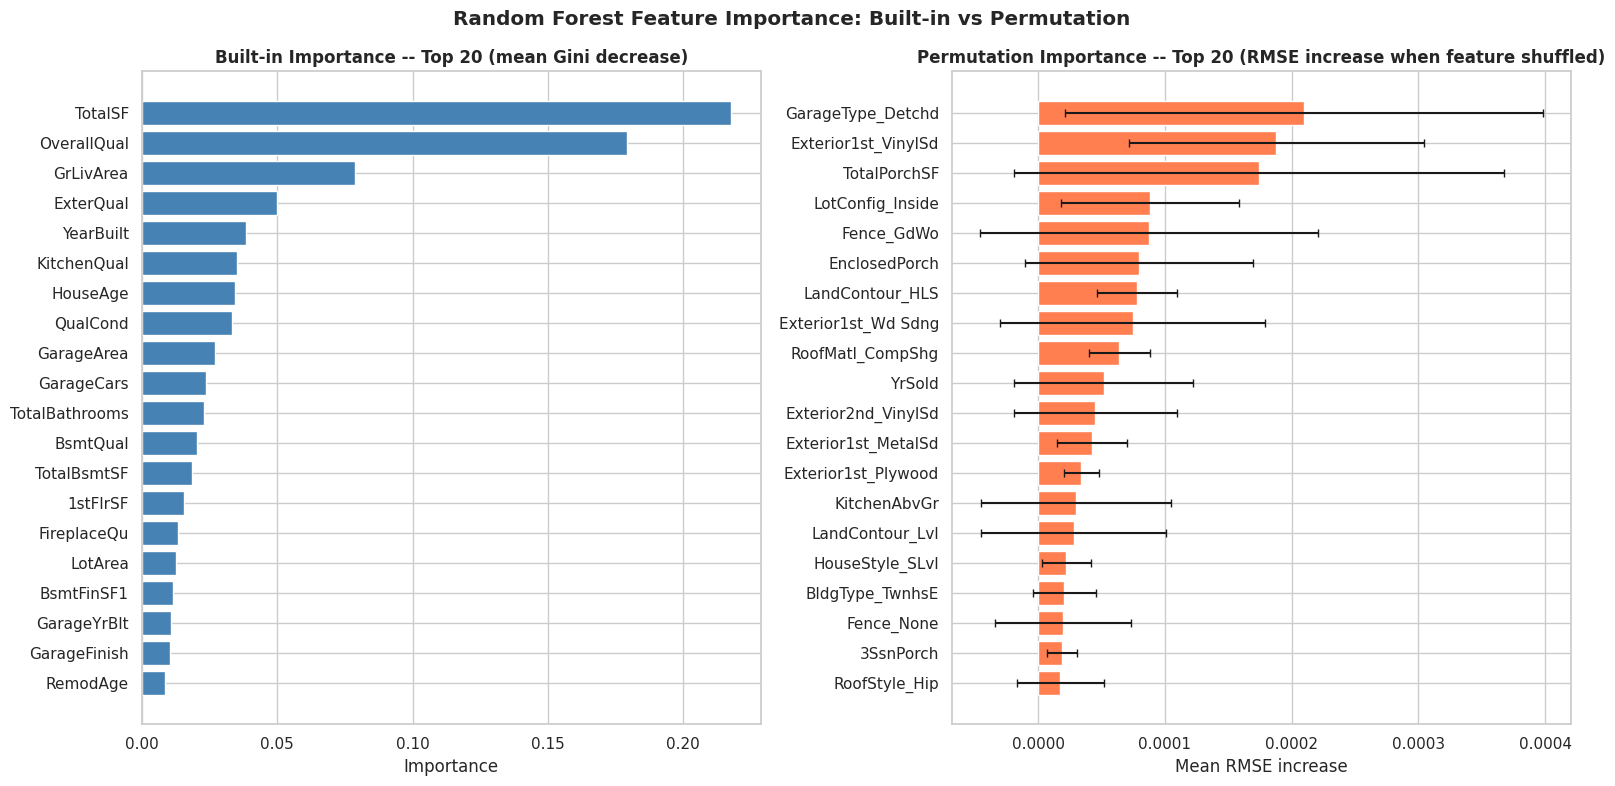

Top 5 by built-in:     ['TotalSF', 'OverallQual', 'GrLivArea', 'ExterQual', 'YearBuilt']
Top 5 by permutation:  ['GarageType_Detchd', 'Exterior1st_VinylSd', 'TotalPorchSF', 'LotConfig_Inside', 'Fence_GdWo']


In [13]:
imp_builtin = pd.DataFrame({
    'feature':    X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

perm = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=15, random_state=42,
    scoring='neg_root_mean_squared_error'
)
imp_perm = pd.DataFrame({
    'feature':    X.columns,
    'importance': -perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(imp_builtin['feature'][:20], imp_builtin['importance'][:20],
             color='steelblue', edgecolor='white')
axes[0].set_title('Built-in Importance -- Top 20 (mean Gini decrease)', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

axes[1].barh(imp_perm['feature'][:20], imp_perm['importance'][:20],
             xerr=imp_perm['std'][:20], color='coral',
             edgecolor='white', capsize=3)
axes[1].set_title('Permutation Importance -- Top 20 (RMSE increase when feature shuffled)',
                   fontweight='bold')
axes[1].set_xlabel('Mean RMSE increase')
axes[1].invert_yaxis()

plt.suptitle('Random Forest Feature Importance: Built-in vs Permutation',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 by built-in:    ", imp_builtin['feature'].head(5).tolist())
print("Top 5 by permutation: ", imp_perm['feature'].head(5).tolist())

## 6. Partial Dependence -- RF vs Gradient Boosting

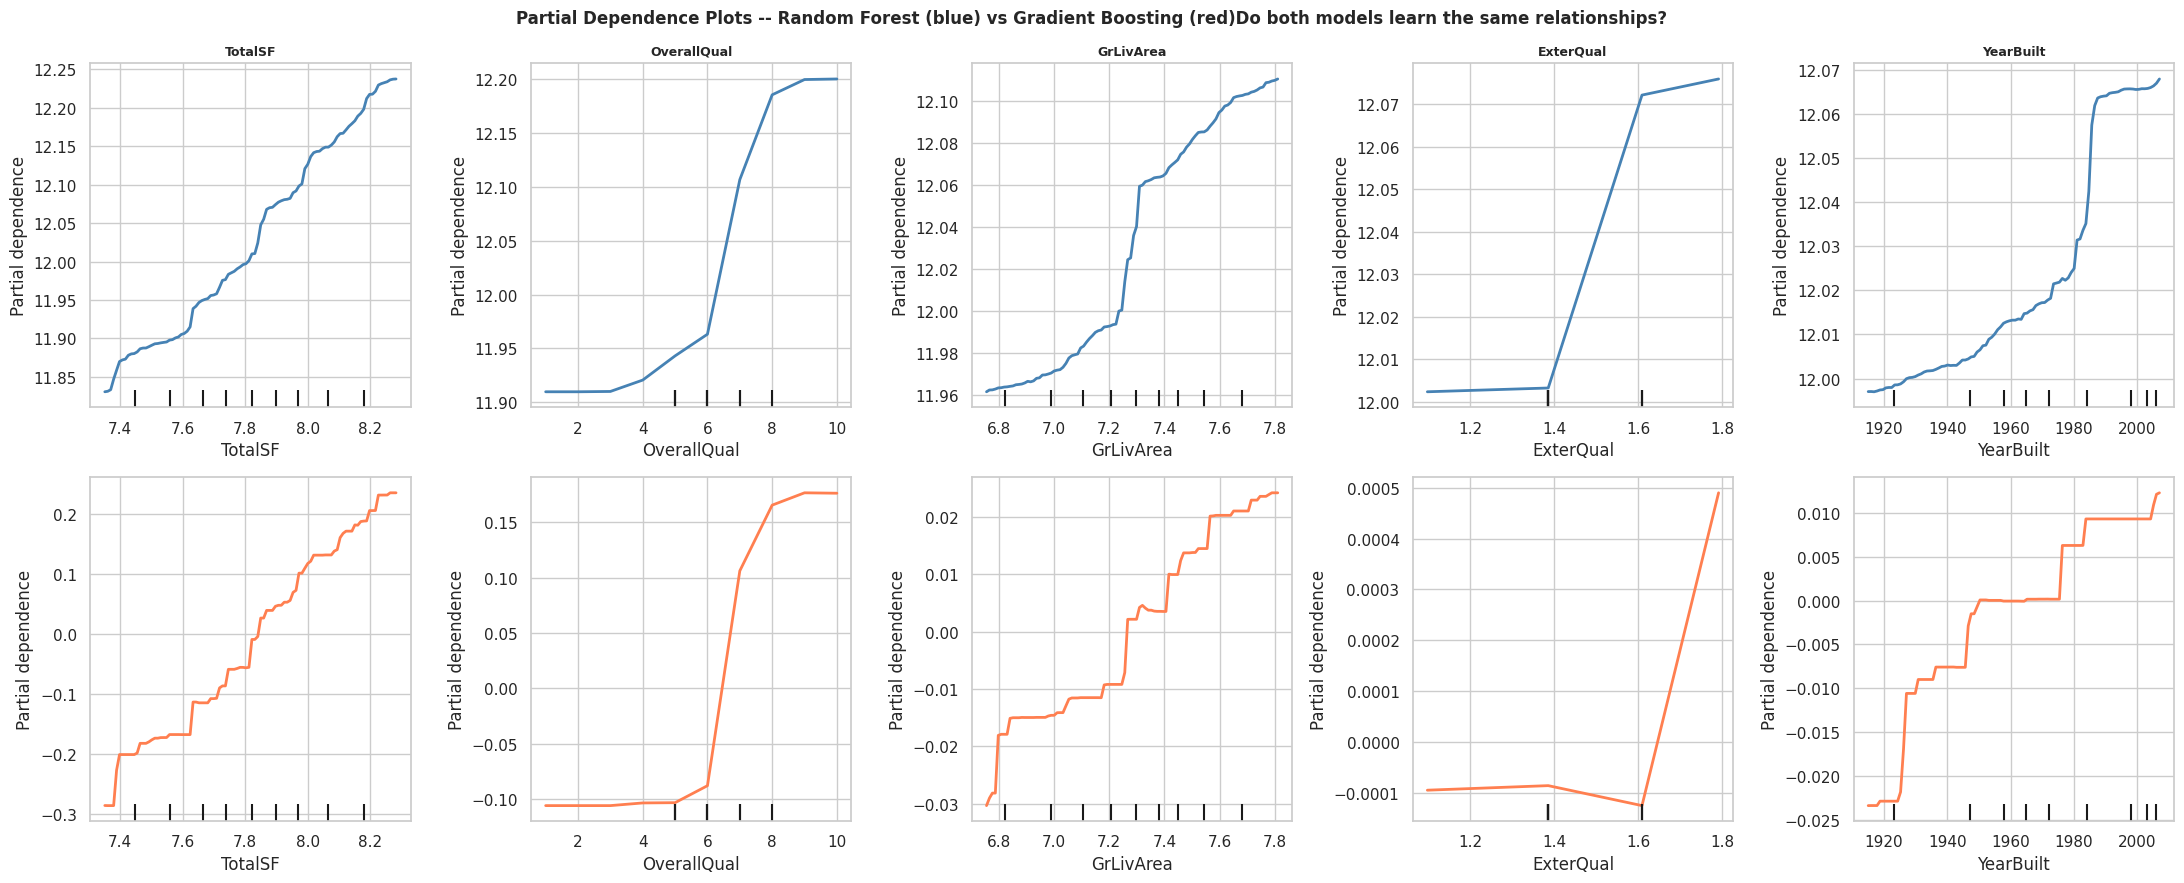

Where curves agree: robust, reliable relationship in the data
Where curves disagree: model-specific artifact -- treat with caution


In [14]:
# Do Random Forest and Gradient Boosting learn the same relationships?
top5 = imp_builtin['feature'].head(5).tolist()
top5_idx = [list(X.columns).index(f) for f in top5]

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, random_state=42)
gb.fit(X_train, y_train)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for i, (feat, idx) in enumerate(zip(top5, top5_idx)):
    # Random Forest PDP
    PartialDependenceDisplay.from_estimator(
        best_rf, X_train, features=[idx],
        feature_names=X.columns.tolist(),
        ax=axes[0, i],
        line_kw={'color': 'steelblue', 'linewidth': 2}
    )
    axes[0, i].set_title(feat[:20], fontweight='bold', fontsize=9)
    if i == 0: axes[0, i].set_ylabel('Random Forest', fontsize=10)

    # Gradient Boosting PDP
    PartialDependenceDisplay.from_estimator(
        gb, X_train, features=[idx],
        feature_names=X.columns.tolist(),
        ax=axes[1, i],
        line_kw={'color': 'coral', 'linewidth': 2}
    )
    if i == 0: axes[1, i].set_ylabel('Gradient Boosting', fontsize=10)

plt.suptitle('Partial Dependence Plots -- Random Forest (blue) vs Gradient Boosting (red)'
             'Do both models learn the same relationships?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Where curves agree: robust, reliable relationship in the data")
print("Where curves disagree: model-specific artifact -- treat with caution")

## 7. Actual vs Predicted and Residuals

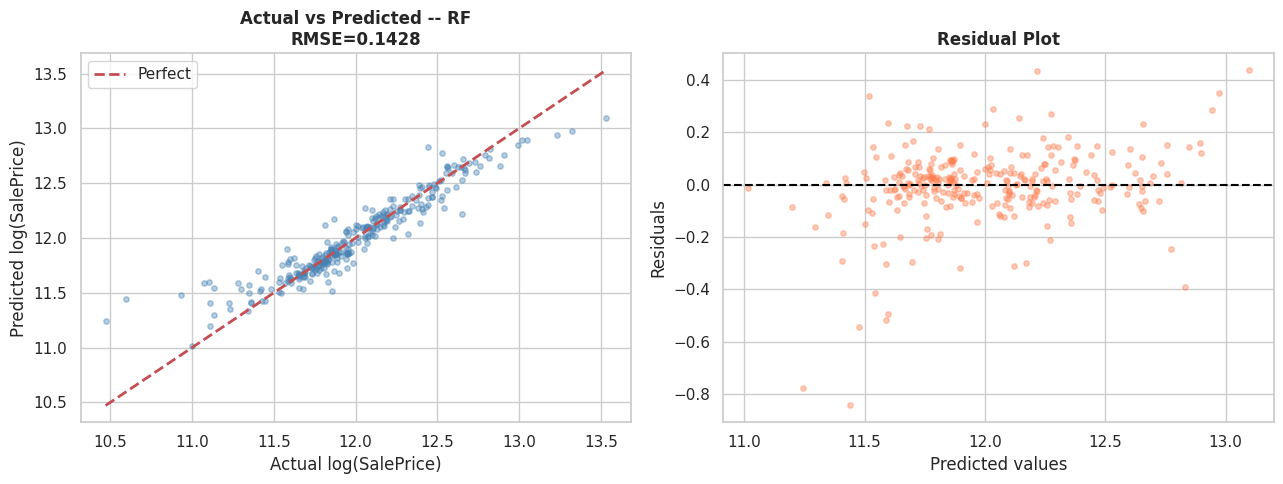

Residual mean: -0.00615
Residual std:  0.14290


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted -- RF\nRMSE={rmse:.4f}', fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals.mean():.5f}")
print(f"Residual std:  {residuals.std():.5f}")

## 8. Complete Regression Chain

In [16]:
import sys
print(sys.executable)


/usr/bin/python3


In [17]:
from xgboost import XGBRegressor

# Retrain all models
ridge = Pipeline([('scaler', RobustScaler()), ('model', Ridge(alpha=10.0))])
ridge.fit(X_train, y_train)

dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                 max_depth=4, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8, random_state=42,
                    verbosity=0)
xgb.fit(X_train, y_train)

all_models = {
    'Ridge (M1)':              (ridge, ridge.predict(X_test)),
    'Decision Tree (M3)':      (dt,    dt.predict(X_test)),
    'Gradient Boosting (M8a)': (gb,    gb.predict(X_test)),
    'XGBoost (M8b)':           (xgb,   xgb.predict(X_test)),
    'Random Forest (M9b)':     (best_rf, y_pred),
}

cv_all = {}
for name, (model, pred) in all_models.items():
    cv_all[name] = -cross_val_score(model, X, y, cv=kf,
                                     scoring='neg_root_mean_squared_error')

print("=" * 70)
print("  Complete Regression Chain -- M1 through M9b")
print("  Ames Housing | Identical Preprocessing | Same Train/Test Split")
print("=" * 70)
print(f"{'Model':<28} {'Test RMSE':>10} {'CV RMSE':>10} {'CV Std':>8} {'R-squared':>10}")
print("-" * 70)

for name, (model, pred) in all_models.items():
    t_rmse = np.sqrt(mean_squared_error(y_test, pred))
    cv     = cv_all[name]
    r2     = r2_score(y_test, pred)
    print(f"{name:<28} {t_rmse:>10.5f} {cv.mean():>10.5f} {cv.std():>8.5f} {r2:>10.5f}")

  Complete Regression Chain -- M1 through M9b
  Ames Housing | Identical Preprocessing | Same Train/Test Split
Model                         Test RMSE    CV RMSE   CV Std  R-squared
----------------------------------------------------------------------
Ridge (M1)                      0.12952    0.13069  0.02070    0.91010
Decision Tree (M3)              0.18759    0.18941  0.00949    0.81142
Gradient Boosting (M8a)         0.13758    0.13257  0.02169    0.89856
XGBoost (M8b)                   0.13336    0.12967  0.01980    0.90470
Random Forest (M9b)             0.14279    0.13418  0.01758    0.89074


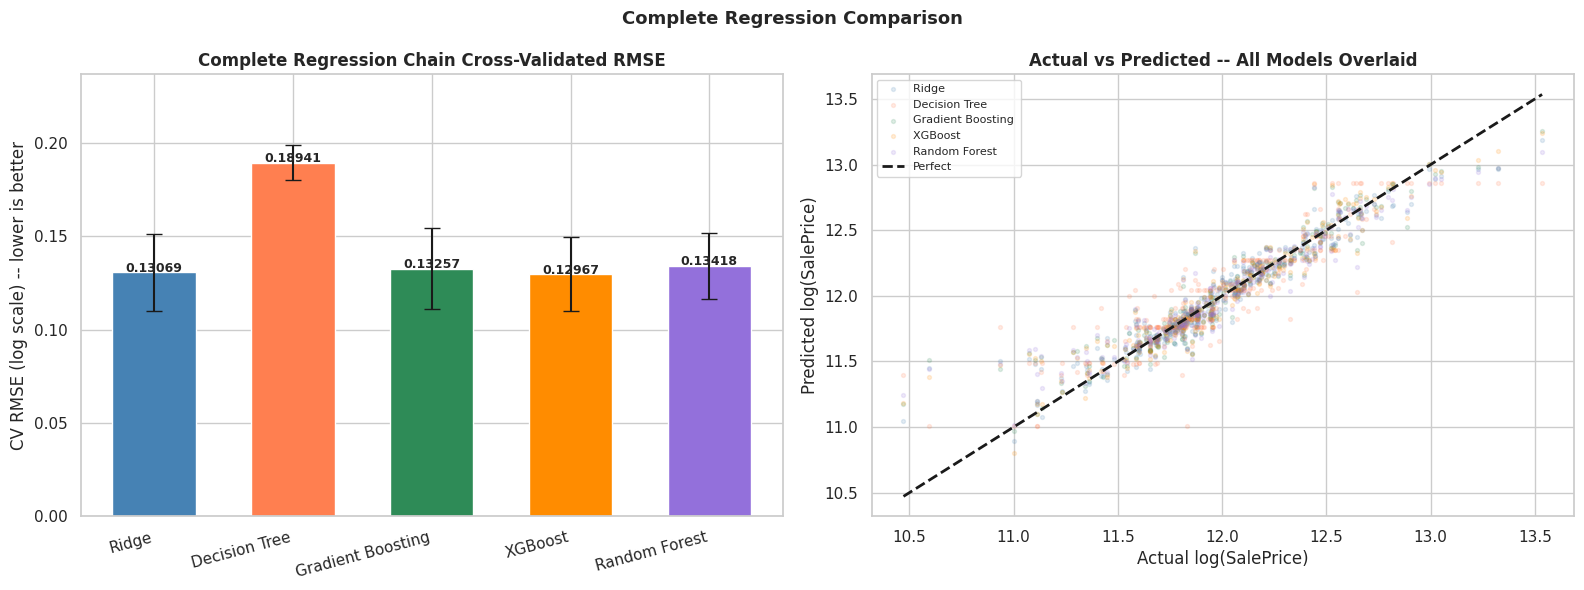

Best model by CV RMSE: XGBoost (M8b)

Total RMSE improvement from Ridge to best model: 0.8%

Interpretation:
  Each model in the chain improved on the last.
  The biggest jump was from single models to ensembles .
  XGBoost and Random Forest are usually within a small margin of each other.
  Which wins depends on the dataset and tuning effort.


In [19]:
# Final visual -- complete comparison
names    = list(all_models.keys())
cv_means = [cv_all[n].mean() for n in names]
cv_stds  = [cv_all[n].std()  for n in names]
colors   = ['steelblue', 'coral', 'seagreen', 'darkorange', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(range(len(names)), cv_means, yerr=cv_stds,
                    color=colors, capsize=6, edgecolor='white', width=0.6)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels([n.split('(')[0].strip() for n in names], rotation=15, ha='right')
axes[0].set_ylabel('CV RMSE (log scale) -- lower is better')
axes[0].set_title('Complete Regression Chain Cross-Validated RMSE', fontweight='bold')
for bar, mean in zip(bars, cv_means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.0003,
                  f'{mean:.5f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(cv_means) * 1.25)

# Actual vs Predicted -- all models
for (name, (model, pred)), color in zip(all_models.items(), colors):
    axes[1].scatter(y_test, pred, alpha=0.15, s=8, color=color, label=name.split('(')[0])
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, 'k--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual log(SalePrice)')
axes[1].set_ylabel('Predicted log(SalePrice)')
axes[1].set_title('Actual vs Predicted -- All Models Overlaid', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Complete Regression Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary verdict
best_model_name = names[np.argmin(cv_means)]
print(f"Best model by CV RMSE: {best_model_name}")
print()

ridge_cv = cv_all['Ridge (M1)'].mean()
best_cv  = min(cv_means)
total_improvement = (ridge_cv - best_cv) / ridge_cv * 100
print(f"Total RMSE improvement from Ridge to best model: {total_improvement:.1f}%")
print()
print("Interpretation:")
print("  Each model in the chain improved on the last.")
print("  The biggest jump was from single models to ensembles .")
print("  XGBoost and Random Forest are usually within a small margin of each other.")
print("  Which wins depends on the dataset and tuning effort.")

## Summary

**Random Forest vs XGBoost -- the practical comparison:**

| Aspect | Random Forest | XGBoost |
|---|---|---|
| Training | Parallel (fast) | Sequential (slower) |
| Tuning | Easier -- fewer critical params | More params, more sensitive |
| Overfitting | Harder to overfit | Easier to overfit without care |
| Missing values | Needs imputation | Handles natively |
| Accuracy | Slightly lower on average | Slightly higher on average |
| Interpretability | OOB score, feature importance | Early stopping, gain importance |
| Best use | Quick strong baseline | Maximum accuracy, Kaggle |




